Es una herramienta que mezcla todo lo que hemos visto anteriormente. Es un ecosistema completo que nos permite:
- Es una herramienta para hacer AutoML, que prueba un monton de modelos.
- Podemos hacer DataWranling
- Deployments de nuestros modelos utilizando ML Flow.

Es util usarlo para hacer unas exploracion cuando no tienes mucha idea al principio de qué cosas funcionan bien, cuando estamos empezando con ML.

Una vez hecho un descubrimiento superficial con PyCaret, si queremos afinar programaremos nosotros nuestro modelo para ajustarlo a nuestro caso y datos.

MLFlow: https://towardsdatascience.com/track-your-ml-models-as-pro-track-them-with-mlflow-11fc5486e389

# **PyCaret**

Pycaret is more than autoML. It is a full ecosystem with ever growing functions, from data wrangling, to autoML, model deployment (mlflow), etc.

However, in this short intro, we are just focusing in the autoML part.

As stated by their authors "PyCaret i an open-source, low-code machine learning library in Python".

Check https://pycaret.org/ for more info and detailed quick guides or advanced tutorials.


This notebook is based on the following tutorial:
https://towardsdatascience.com/pycaret-better-machine-learning-with-python-58b202806d1e

## **Install PyCaret**

In [1]:
!pip install pycaret['full']
#!pip install pycaret

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 791.7 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of category-encoders to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.0/4.0 MB 68.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of flask to determine which version is compatible with other requirements. This could take a while.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 2.8 MB/s eta 0:00:00
  Preparing me

In [2]:
# as for april 2021, I think this is no longer needed:
#from pycaret.utils import enable_colab

#enable_colab()

In [3]:
# 2021/10/24: it is neccesary to solve an error when loadding pycaret.classification below.
# see https://github.com/pycaret/pycaret/issues/1755 for more info.
# the issue has priorityhigh, so it should be fixed in a few days.
# !pip install pyyaml==5.4.1

## **Load PyCaret**

In [1]:
from pycaret.classification import *
from pycaret.datasets import get_data

List all available example datasets

In [2]:
get_data('index')

,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


,Dataset,Data Types,Default Task,Target Variable 1,Target Variable 2,# Instances,# Attributes,Missing Values
0,anomaly,Multivariate,Anomaly Detection,NaN,NaN,1000,10,N
1,france,Multivariate,Association Rule Mining,InvoiceNo,Description,8557,8,N
2,germany,Multivariate,Association Rule Mining,InvoiceNo,Description,9495,8,N
3,bank,Multivariate,Classification (Binary),deposit,NaN,45211,17,N
4,blood,Multivariate,Classification (Binary),Class,NaN,748,5,N
5,cancer,Multivariate,Classification (Binary),Class,NaN,683,10,N
6,credit,Multivariate,Classification (Binary),default,NaN,24000,24,N
7,diabetes,Multivariate,Classification (Binary),Class variable,NaN,768,9,N
8,electrical_grid,Multivariate,Classification (Binary),stabf,NaN,10000,14,N
9,employee,Multivariate,Classification (Binary),left,NaN,14999,10,N


Load an example dataset

In [3]:
diabetes = get_data('diabetes')


,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
diabetes

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


## **Setup a PyCaret experiment:**

In [6]:
exp_clf = setup(diabetes, target='Class variable')

,Description,Value
0,Session id,8818
1,Target,Class variable
2,Target type,Binary
3,Original data shape,"(768, 9)"
4,Transformed data shape,"(768, 9)"
5,Transformed train set shape,"(537, 9)"
6,Transformed test set shape,"(231, 9)"
7,Numeric features,8
8,Preprocess,True
9,Imputation type,simple


En PyCaret, cuando ejecutas la función `setup()`, se genera un resumen con la configuración y transformaciones que se aplicarán a tus datos antes de entrenar los modelos. Estos campos representan:

1. **Session ID (Session id):**  
   - Es el número que PyCaret usa para controlar la reproducibilidad. Actúa como una semilla aleatoria para dividir los datos y entrenar modelos.  
   
2. **Target (Target):**  
   - Indica la columna objetivo que deseas predecir. En tu caso, se llama “Class variable”.

3. **Target Type (Target type):**  
   - Informa si el problema es de clasificación binaria, multiclase o regresión. Aquí aparece “Binary”, indicando que es un problema de clasificación binaria.

4. **Original Data Shape (Original data shape):**  
   - Muestra las dimensiones del conjunto de datos original (número de filas y columnas). En tu ejemplo: `(768, 9)`.

5. **Transformed Data Shape (Transformed data shape):**  
   - Indica la forma (filas y columnas) del conjunto de entrenamiento después de aplicar las transformaciones y preprocesamientos (si los hubiera). En tu caso, sigue siendo `(768, 9)`, lo que sugiere que no se eliminaron columnas ni filas, pero sí se pudo haber realizado alguna transformación interna.

6. **Transformed Test Set Shape (Transformed test set shape):**  
   - Muestra el tamaño (filas y columnas) del conjunto de prueba tras las mismas transformaciones. Aquí: `(231, 9)`.

7. **Numeric Features (Numeric features):**  
   - Número de variables numéricas que PyCaret identificó en tu dataset. Aparece como `8`.

8. **Preprocess:**  
   - Indica si PyCaret está realizando o no un preprocesamiento automático. En tu caso, es `True`.

9. **Imputation Type (Imputation type):**  
   - El tipo de imputación de datos faltantes (missing values) que PyCaret aplicará. Aquí se muestra “simple”.

10. **Numeric Imputation (Numeric imputation):**  
    - Especifica cómo se imputan (rellenan) los valores faltantes en las columnas numéricas (por ejemplo, con la media, mediana, etc.). En tu caso, se usa la “mean”.

11. **Categorical Imputation (Categorical imputation):**  
    - Define cómo se imputan las variables categóricas (por ejemplo, con la moda). En tu caso, se usa la “mode”.

12. **Fold Generator (Fold generator):**  
    - Indica qué tipo de validación cruzada (Cross Validation) se está usando. Aquí se muestra “StratifiedKFold”, que mantiene la proporción de clases en cada pliegue.

13. **Fold Number (Fold number):**  
    - Número de folds (pliegues) utilizados en la validación cruzada. Aquí, `10`.

14. **CPU Jobs (CPU Jobs):**  
    - El número de núcleos de CPU que PyCaret puede usar en paralelo. “-1” significa que usará todos los núcleos disponibles.

15. **Use GPU (Use gpu):**  
    - Indica si PyCaret usará la GPU para acelerar algunos algoritmos compatibles. En tu caso, es `False`.

16. **Log Experiment (Log Experiment):**  
    - Indica si se está registrando el experimento en una herramienta de seguimiento (por ejemplo, MLflow). Aquí, `False` significa que no se está registrando automáticamente.

17. **Experiment Name (Experiment Name):**  
    - Nombre asignado al experimento si se habilita el registro (logging) en PyCaret. Aquí aparece `clf-default-name`.

18. **USI (USI):**  
    - Es el “Unique Session ID” de PyCaret. Se usa internamente para identificar la sesión.

Todo lo anterior se puede configurar, pasandole mas hiperparametros al metodo setup(), le puedo decir si quiero aplicar PCA por ejemplo. Incluso hay un metodo, para en caso de que el conjunto de datos no fuese balanceado, que crease datos artificiales para balancear el dataset, con el metodo SMOTE.

List all available models in PyCaret:

In [7]:
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


Fit all models with the default parameters' configuration for each one:

In [8]:
compare_models()

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
ridge,Ridge Classifier,0.7673,0.8127,0.5605,0.7190,0.6241,0.4600,0.4715,0.0320
rf,Random Forest Classifier,0.7654,0.8153,0.5772,0.7054,0.6307,0.4618,0.4698,0.2830
lda,Linear Discriminant Analysis,0.7654,0.8135,0.5661,0.7089,0.6246,0.4578,0.4673,0.0330
lr,Logistic Regression,0.7617,0.8161,0.5608,0.7072,0.6182,0.4494,0.4608,0.8890
nb,Naive Bayes,0.7599,0.8136,0.6146,0.6745,0.6403,0.4610,0.4644,0.0290
et,Extra Trees Classifier,0.7524,0.7972,0.5658,0.6771,0.6126,0.4331,0.4396,0.1840
catboost,CatBoost Classifier,0.7487,0.8149,0.5450,0.6824,0.6015,0.4215,0.4304,2.2880
gbc,Gradient Boosting Classifier,0.7431,0.8085,0.5667,0.6525,0.6024,0.4150,0.4202,0.3410
qda,Quadratic Discriminant Analysis,0.7375,0.8030,0.5500,0.6450,0.5902,0.3998,0.4045,0.0600
ada,Ada Boost Classifier,0.7357,0.7933,0.5243,0.6566,0.5782,0.3902,0.3986,0.3660


Processing:   0%|          | 0/69 [00:00<?, ?it/s]

RidgeClassifier(alpha=1.0, class_weight=None, copy_X=True, fit_intercept=True,
                max_iter=None, positive=False, random_state=8818, solver='auto',
                tol=0.0001)

Select one model that has given promising results for further fine-tuning:

Va a ejecutar catboost, con un monton de hiperparámetros. Va a hacer esa busqueda en grid, que habíamos echo en la unidad anterior.

In [9]:
catb = create_model('catboost')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8333,0.8827,0.5789,0.9167,0.7097,0.6010,0.6322
1,0.7407,0.7353,0.6316,0.6316,0.6316,0.4316,0.4316
2,0.6481,0.7654,0.3684,0.5000,0.4242,0.1792,0.1835
3,0.7222,0.8195,0.5789,0.6111,0.5946,0.3836,0.3839
4,0.7407,0.7684,0.5263,0.6667,0.5882,0.4028,0.4088
5,0.7407,0.8376,0.5789,0.6471,0.6111,0.4176,0.4190
6,0.7407,0.8180,0.6316,0.6316,0.6316,0.4316,0.4316
7,0.7170,0.8206,0.4444,0.6154,0.5161,0.3234,0.3320
8,0.7925,0.8381,0.5000,0.8182,0.6207,0.4890,0.5171


Processing:   0%|          | 0/4 [00:00<?, ?it/s]

Plot several performance metrics for the model:

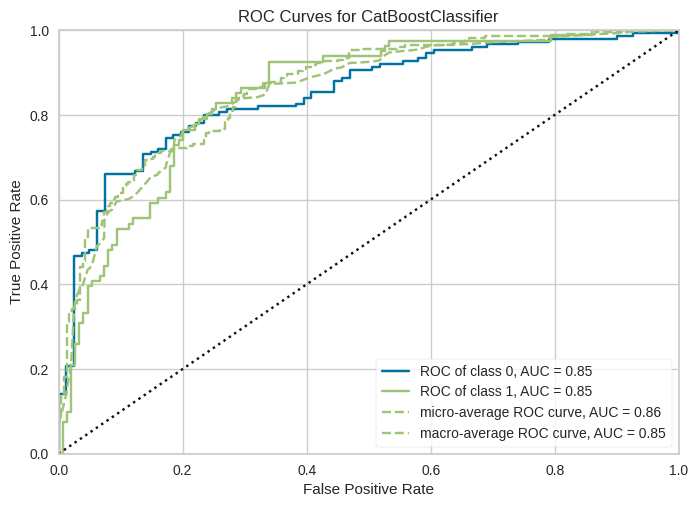

In [10]:
plot_model(catb)

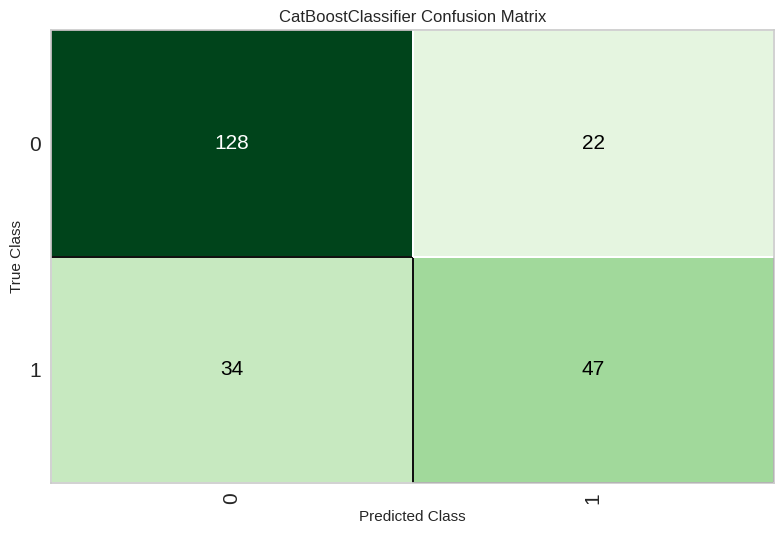

In [11]:
plot_model(catb, 'confusion_matrix')

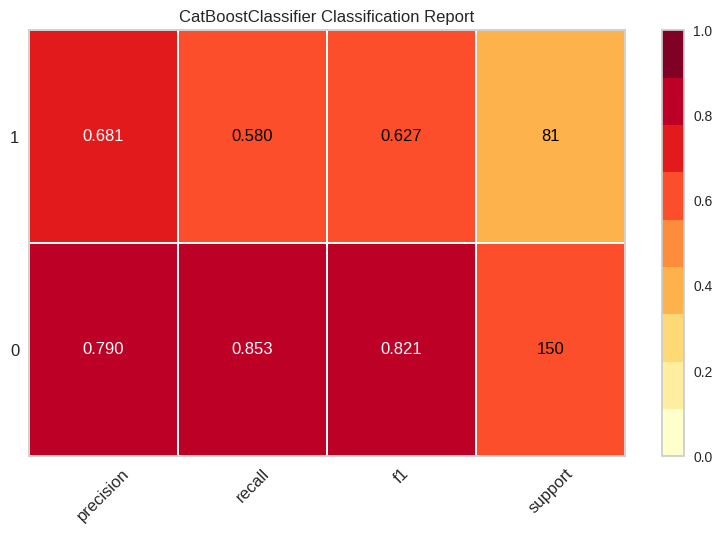

In [12]:
plot_model(catb, 'class_report')

In [13]:
!pip install shap

### **Use SHAP values to interpret the model**

Before, check this explanation: https://astrobenhart.medium.com/how-to-use-shap-with-pycaret-dc9a31278621


**Explaining the entire dataset: summary plots**

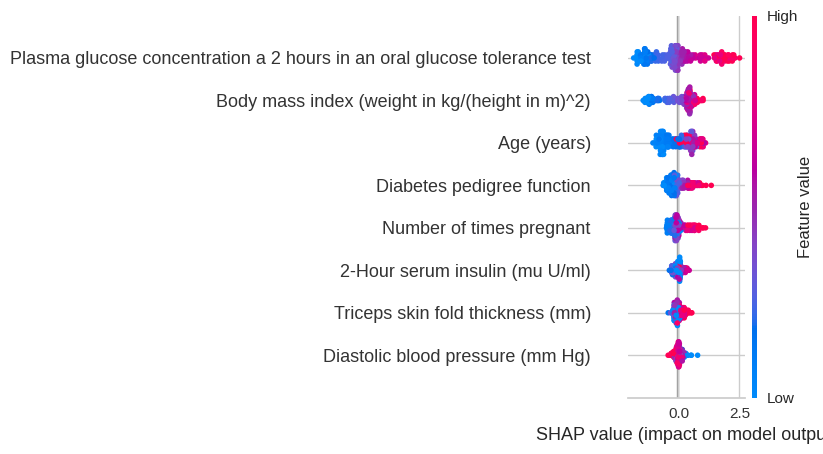

In [14]:
interpret_model(catb)

- Las variables (eje Y) están ordenadas por su relevancia.
- El eje X refleja el valor SHAP: cuanto más a la derecha, mayor contribución positiva a la clase; cuanto más a la izquierda, más contribución negativa.
- Cada punto es una instancia, y su color indica si el valor de la variable es alto (rojo) o bajo (azul).

**Explaining a single feature: dependence plots**

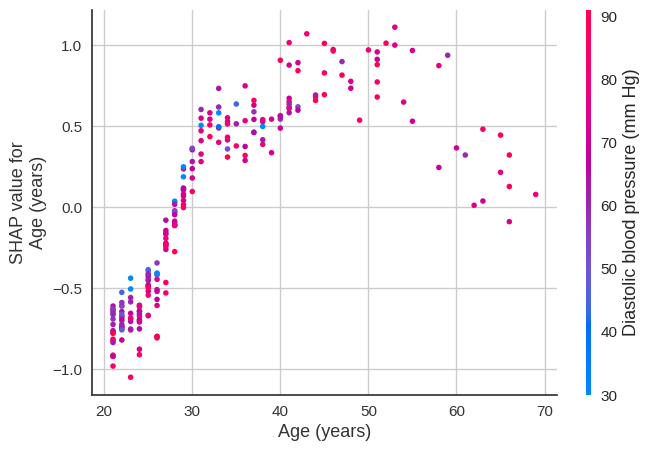

In [15]:
interpret_model(catb, plot='correlation', feature='Age (years)')

In [16]:
y_pred = predict_model(catb)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,CatBoost Classifier,0.7576,0.8479,0.5802,0.6812,0.6267,0.4489,0.4520


In [17]:
y_pred.shape

(231, 11)

In [18]:
y_pred.head(20)

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable,prediction_label,prediction_score
730,3,130,78,23,79,28.400000,0.323,34,1,0,0.7534
371,0,118,64,23,89,0.000000,1.731,21,0,0,0.9432
677,0,93,60,0,0,35.299999,0.263,25,0,0,0.9028
285,7,136,74,26,135,26.000000,0.647,51,0,1,0.5381
479,4,132,86,31,0,28.000000,0.419,63,0,0,0.7268
560,6,125,76,0,0,33.799999,0.121,54,1,0,0.6516
117,5,78,48,0,0,33.700001,0.654,25,0,0,0.9018
671,1,99,58,10,0,25.400000,0.551,21,0,0,0.9845
198,4,109,64,44,99,34.799999,0.905,26,1,0,0.6375
254,12,92,62,7,258,27.600000,0.926,44,1,0,0.6008


In [19]:
interpret_model(catb, plot='reason', observation=0)

In [20]:
interpret_model(catb, plot='reason', observation=1)

In [21]:
interpret_model(catb, plot='reason', observation=5)

In [22]:
evaluate_model(catb)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [23]:
finalize_model(catb)

Pipeline(memory=Memory(location=None),
         steps=[('numerical_imputer',
                 TransformerWrapper(exclude=None,
                                    include=['Number of times pregnant',
                                             'Plasma glucose concentration a 2 '
                                             'hours in an oral glucose '
                                             'tolerance test',
                                             'Diastolic blood pressure (mm Hg)',
                                             'Triceps skin fold thickness (mm)',
                                             '2-Hour serum insulin (mu U/ml)',
                                             'Body mass index (weight in '
                                             'kg/(height in m)^2)',
                                             'Diabetes pedigre...
                                    transformer=SimpleImputer(add_indicator=False,
                                                              copy=True,
                                                              fill_value=None,
                                                              keep_empty_features=False,
                                                              missing_values=nan,
                                                              strategy='most_frequent'))),
                ('clean_column_names',
                 TransformerWrapper(exclude=None, include=None,
                                    transformer=CleanColumnNames(match='[\\]\\[\\,\\{\\}\\"\\:]+'))),
                ('actual_estimator',
                 <catboost.core.CatBoostClassifier object at 0x78ee76a1bfd0>)],
         verbose=False)

In [24]:
save_model(catb, 'diabetes_catboost')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['Number of times pregnant',
                                              'Plasma glucose concentration a 2 '
                                              'hours in an oral glucose '
                                              'tolerance test',
                                              'Diastolic blood pressure (mm Hg)',
                                              'Triceps skin fold thickness (mm)',
                                              '2-Hour serum insulin (mu U/ml)',
                                              'Body mass index (weight in '
                                              'kg/(height in m)^2)',
                                              'Diabetes pedigre...
                                     transformer=SimpleImputer(add_indicator=False,
                                    

In [25]:
model = load_model('diabetes_catboost')

Transformation Pipeline and Model Successfully Loaded


# Let's repeat all process with a sklearn dataset

this is to check if there are any customization in the datasets

In [ ]:
from sklearn.datasets import load_wine

In [ ]:
data = load_wine(as_frame=True)

In [ ]:
data.data

In [ ]:
data.frame

In [ ]:
exp_clf = setup(data=data.frame, target='target')

In [ ]:
compare_models()

In [ ]:
wine_model = create_model('catboost')

In [ ]:
predictions = predict_model(wine_model)

In [ ]:
evaluate_model(wine_model)

In [ ]:
interpret_model(wine_model, plot='summary')

In [ ]:
# Partial Dependence plot: influence of the 4th feature (Magnesium) on the first class (0)
# this is not solved for multiclass (no way of specifying the class to check the feature's influence on it)
# I think this is just for regression problems.
interpret_model(wine_model, plot='pdp', feature='color_intensity')

# this rises an error because there is no way of specifying the class in a multiclass (multioutput) model:
# interpret_model(wine_model, plot='correlation', feature='Magnesium')

In [ ]:
interpret_model(wine_model, plot='msa')

In [ ]:
#interpret_model(wine_model, plot='reason', observation=0)

# this rises an error because there is no way of specifying the class in a multiclass (multioutput) model

Anyway, it is always possible to use the standar shap functions, instead of those provided by pycaret, which is more versatile and powerfull by the time being:

In [ ]:
# no need to install shap, as it comes installed with pycaret
import shap

In [ ]:
explainer = shap.TreeExplainer(wine_model)
shap_values = explainer.shap_values(data.data)

In [ ]:
shap_values[0][0] #dimensionality in this case is: shap_values[0:2][0:12]

In [ ]:
# Partial Dependence plot: influence of the 4th feature (Magnesium) on the first class (0)
shap.dependence_plot('magnesium', shap_values[0], data.data) # SHAP automatically selects another feature for coloring